#Classification Model....

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,classification_report,confusion_matrix)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
df=pd.read_csv("crop-yield.csv")
df.head()

,N,P,K,Soil_pH,Soil_Moisture,Soil_Type,Organic_Carbon,Temperature,Humidity,Rainfall,Sunlight_Hours,Wind_Speed,Region,Altitude,Season,Crop_Type,Irrigation_Type,Fertilizer_Used,Pesticide_Used,Crop_Yield_ton_per_hectare
0,132,62,22,6.35,59.78,Clay,0.43,22.97,53.89,1305.68,7.73,15.96,Central,36,Rabi,Maize,Canal,223.48,23.36,11.42
1,122,71,66,5.98,25.54,Sandy,0.65,17.00,76.90,1942.05,9.25,12.60,North,1561,Rabi,Potato,Canal,161.54,4.42,23.19
2,44,35,104,8.07,25.87,Sandy,0.79,25.52,44.78,2216.20,8.50,15.63,North,1870,Rabi,Rice,Rainfed,184.62,6.29,7.94
3,136,96,113,4.83,42.97,Silt,0.45,18.59,31.89,607.18,8.75,5.49,East,765,Kharif,Sugarcane,Rainfed,274.02,2.72,72.53
4,101,34,42,5.84,48.01,Silt,0.69,22.74,46.27,483.47,8.00,7.44,Central,1143,Zaid,Wheat,Rainfed,72.69,15.37,6.72


In [5]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

print(f"Missing Values:")
print(f"="*175)
print(f"{missing}")
if missing.sum() > 0:
    print("\nMissing values found. Attempting to fill numerical columns with their mean.")
    numerical_cols = df.select_dtypes(include=np.number).columns
    for col in numerical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].mean())
            print(f"  - Filled missing values in '{col}' with mean: {df[col].mean():.2f}")
    print("Missing numerical values filling complete.")
else:
    print("\nNo missing values found !!")

print(f"\n" +"="*175)
print(f"Duplicate Rows: {duplicates} ")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")
    print(f"New Dataset Shape :{df.shape}")

else:
    print("\nNo duplicates found!")

Missing Values:
N                             0
P                             0
K                             0
Soil_pH                       0
Soil_Moisture                 0
Soil_Type                     0
Organic_Carbon                0
Temperature                   0
Humidity                      0
Rainfall                      0
Sunlight_Hours                0
Wind_Speed                    0
Region                        0
Altitude                      0
Season                        0
Crop_Type                     0
Irrigation_Type               0
Fertilizer_Used               0
Pesticide_Used                0
Crop_Yield_ton_per_hectare    0
dtype: int64

No missing values found !!

Duplicate Rows: 0 

No duplicates found!


In [6]:
target = "Crop_Type"

categorical_cols = [
    'Soil_Type','Region','Season','Irrigation_Type'
]

numerical_cols = [
    col for col in df.columns
    if col not in categorical_cols + [target]
]


In [7]:
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
le_target = LabelEncoder()
df[target] = le_target.fit_transform(df[target])

# mapping check
dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))

{'Cotton': np.int64(0),
 'Maize': np.int64(1),
 'Potato': np.int64(2),
 'Rice': np.int64(3),
 'Sugarcane': np.int64(4),
 'Wheat': np.int64(5)}

In [8]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

In [10]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred, average='weighted')
    precision=precision_score(y_test, y_pred, average='weighted')
    f1=f1_score(y_test, y_pred, average='weighted')
    results.append([name, acc,recall,precision,f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy","Recall","Precision","F1_score"])
results_df.sort_values(by="Accuracy", ascending=False)


,Model,Accuracy,Recall,Precision,F1_score
1,Random Forest,0.6130,0.6130,0.600176,0.603805
4,Naive Bayes,0.5940,0.5940,0.582893,0.584878
0,Decision Tree,0.5895,0.5895,0.586605,0.587752
2,SVM,0.5365,0.5365,0.537710,0.536612
3,KNN,0.3520,0.3520,0.359899,0.351371


In [11]:
best_model_name = results_df.sort_values(
    by="F1_score", ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]
best_model


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


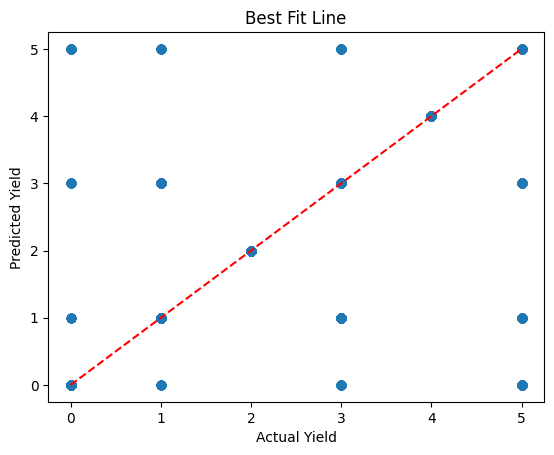

In [12]:
y_pred = best_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Best Fit Line")
plt.show()


In [13]:
y_pred = best_model.predict(X_test)
print("Classification Report For X_test's Predicition with " + best_model_name)
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le_target.classes_
    )
)

Classification Report For X_test's Predicition with Random Forest
              precision    recall  f1-score   support

      Cotton       0.56      0.66      0.61       333
       Maize       0.45      0.55      0.49       332
      Potato       1.00      1.00      1.00       334
        Rice       0.29      0.25      0.27       340
   Sugarcane       1.00      1.00      1.00       327
       Wheat       0.32      0.24      0.27       334

    accuracy                           0.61      2000
   macro avg       0.60      0.62      0.61      2000
weighted avg       0.60      0.61      0.60      2000



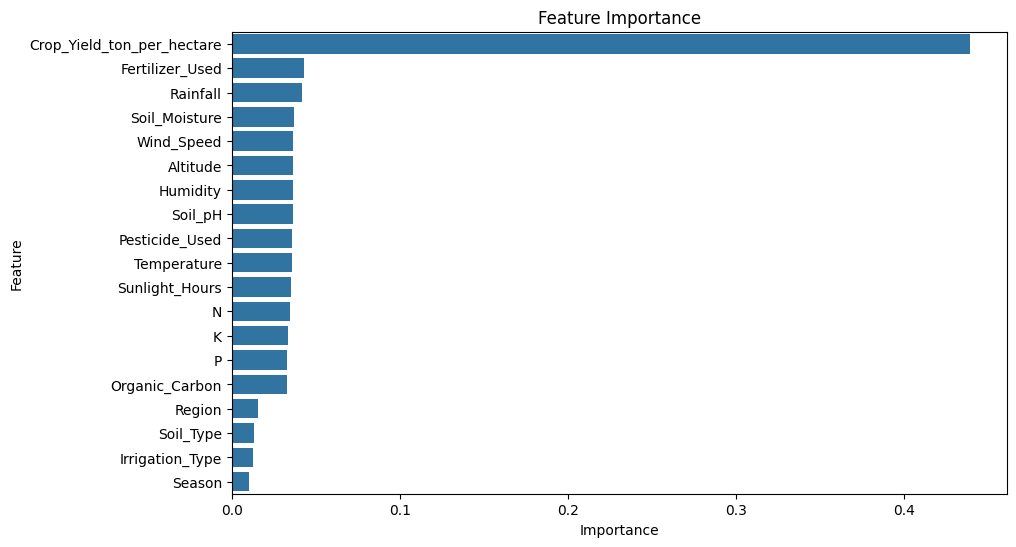

In [14]:
importances = best_model.feature_importances_
features = X.columns

fi = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi)
plt.title("Feature Importance")
plt.show()


In [15]:
input_df = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)
user_features = ['Crop_Yield_ton_per_hectare','Fertilizer_Used','Rainfall', 'Soil_Moisture', 'Wind_Speed']

print("Enter details for prediction:")
for feature in user_features:
    val = float(input(f"Enter {feature}: "))
    input_df[feature] = val

input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])
prediction_encoded = best_model.predict(input_df)
prediction_label = le_target.inverse_transform(prediction_encoded)

print("=" * 100)
print(f"The predicted Best Crop Type is: {prediction_label[0]}")
print("=" * 100)

Enter details for prediction:
The predicted Best Crop Type is: Sugarcane


#Regression Model.....

In [16]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

In [17]:
DF=pd.read_csv("crop-yield.csv")

In [18]:
target = 'Crop_Yield_ton_per_hectare'

categorical_cols = ['Soil_Type','Region','Season','Crop_Type','Irrigation_Type']
numerical_cols = [col for col in DF.columns if col not in categorical_cols + [target]]

In [19]:
for col in numerical_cols:
    Q1 = DF[col].quantile(0.25)
    Q3 = DF[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    DF = DF[(DF[col] >= lower) & (DF[col] <= upper)]

In [20]:
le = LabelEncoder()

for col in categorical_cols:
    DF[col] = le.fit_transform(DF[col])
scaler = StandardScaler()

DF[numerical_cols] = scaler.fit_transform(DF[numerical_cols])
X = DF.drop(target, axis=1)
y = DF[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoost": GradientBoostingRegressor(),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(objective='reg:squarederror')
}


In [22]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results, columns=['Model','R2','MAE','RMSE'])
results_df.sort_values(by='R2', ascending=False)


,Model,R2,MAE,RMSE
2,GradientBoost,0.997939,0.874820,1.095923
4,XGBoost,0.997833,0.896710,1.123983
1,RandomForest,0.997793,0.910112,1.134102
0,Linear,0.133909,16.565416,22.468317
3,SVR,-0.133313,13.467348,25.701802


In [23]:
best_model_name = results_df.sort_values(
    by="R2", ascending=False
).iloc[0]["Model"]

best_model = models[best_model_name]
best_model

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


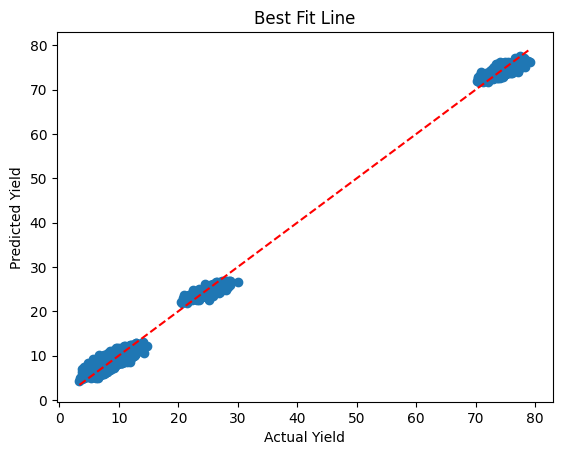

In [24]:
y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Best Fit Line")
plt.show()


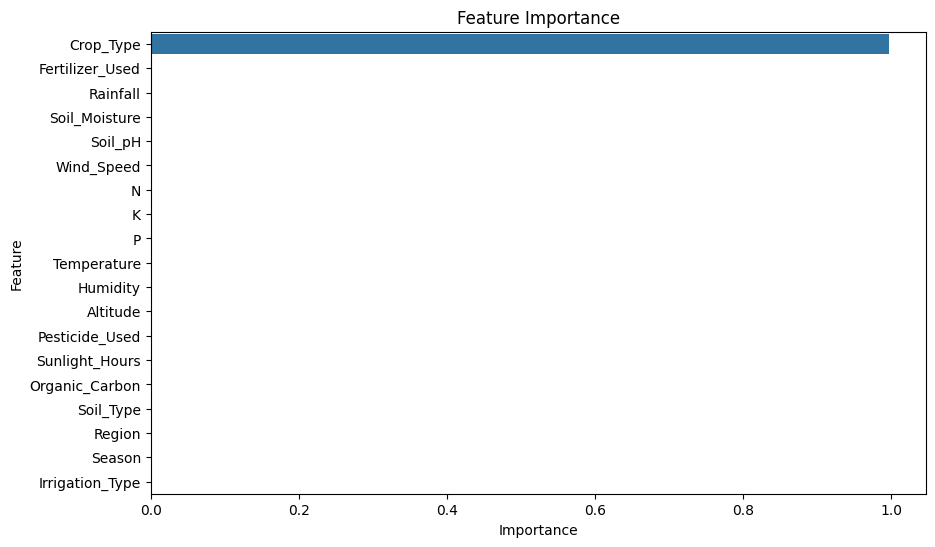

In [25]:
importances = best_model.feature_importances_
features = X.columns

fi = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi)
plt.title("Feature Importance")
plt.show()

In [26]:
input_df = pd.DataFrame(np.zeros((1, X.shape[1])), columns=X.columns)
print("Enter details for yield prediction:")

crop = int(input("\n1.Maize \n2.Potato \n3.Rice \n4.Sugarcane \n5.Wheat \n6.Cotton \nEnter Crop_Type (0-5): "))
input_df['Crop_Type'] = crop

fertilizer_used = float(input("Enter Fertilizer_Used: "))
input_df['Fertilizer_Used'] = fertilizer_used

input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])
prediction_yield = best_model.predict(input_df)

print("=" * 100)
print(f"The predicted Crop Yield is: {prediction_yield[0]:.2f} tons per hectare")
print("=" * 100)

Enter details for yield prediction:
The predicted Crop Yield is: 4.29 tons per hectare
